# Salary Distribution Analysis — Data Jobs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("salaries.csv")

print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80 + "\n")
print(f"Total Records : {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"\nColumns: {', '.join(df.columns.tolist())}")
print("\n" + "="*80 + "\n")
print(df.head())
print("\n" + "="*80 + "\n")


DATASET OVERVIEW

Total Records : 151445
Total Features: 11

Columns: work_year, experience_level, employment_type, job_title, salary, salary_currency, salary_in_usd, employee_residence, remote_ratio, company_location, company_size


   work_year experience_level employment_type       job_title  salary  \
0       2025               EX              FT    Head of Data  348516   
1       2025               EX              FT    Head of Data  232344   
2       2025               SE              FT  Data Scientist  145400   
3       2025               SE              FT  Data Scientist   81600   
4       2025               MI              FT        Engineer  160000   

  salary_currency  salary_in_usd employee_residence  remote_ratio  \
0             USD         348516                 US             0   
1             USD         232344                 US             0   
2             USD         145400                 US             0   
3             USD          81600                 U

## Salary Distribution in Data Jobs

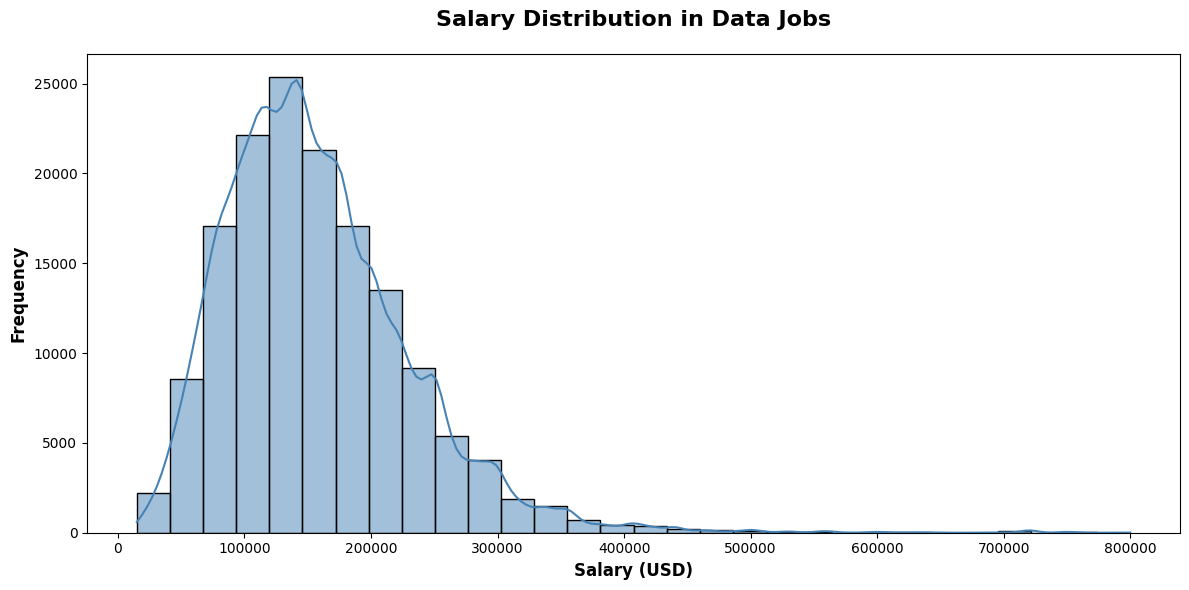

In [2]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(df['salary_in_usd'], bins=30, kde=True, color='steelblue', ax=ax)
ax.set_title("Salary Distribution in Data Jobs", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Salary (USD)", fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [3]:
avg_salary_role = df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False)
top_roles = avg_salary_role.head(10)

print("\n" + "="*80)
print("TOP 10 HIGHEST PAYING DATA JOBS")
print("="*80 + "\n")
for i, (role, sal) in enumerate(top_roles.items(), 1):
    print(f"  {i:>2}. {role:<45} ${sal:>12,.0f}")
print("\n" + "="*80 + "\n")


TOP 10 HIGHEST PAYING DATA JOBS

   1. Research Team Lead                            $     450,000
   2. Analytics Engineering Manager                 $     399,880
   3. Data Science Tech Lead                        $     375,000
   4. Applied AI ML Lead                            $     292,500
   5. Head of Machine Learning                      $     286,806
   6. IT Enterprise Data Architect                  $     284,090
   7. Head of Applied AI                            $     273,875
   8. AIRS Solutions Specialist                     $     263,250
   9. Machine Learning Performance Engineer         $     262,500
  10. Director of Product Management                $     259,156




## Top Paying Data Jobs — Chart

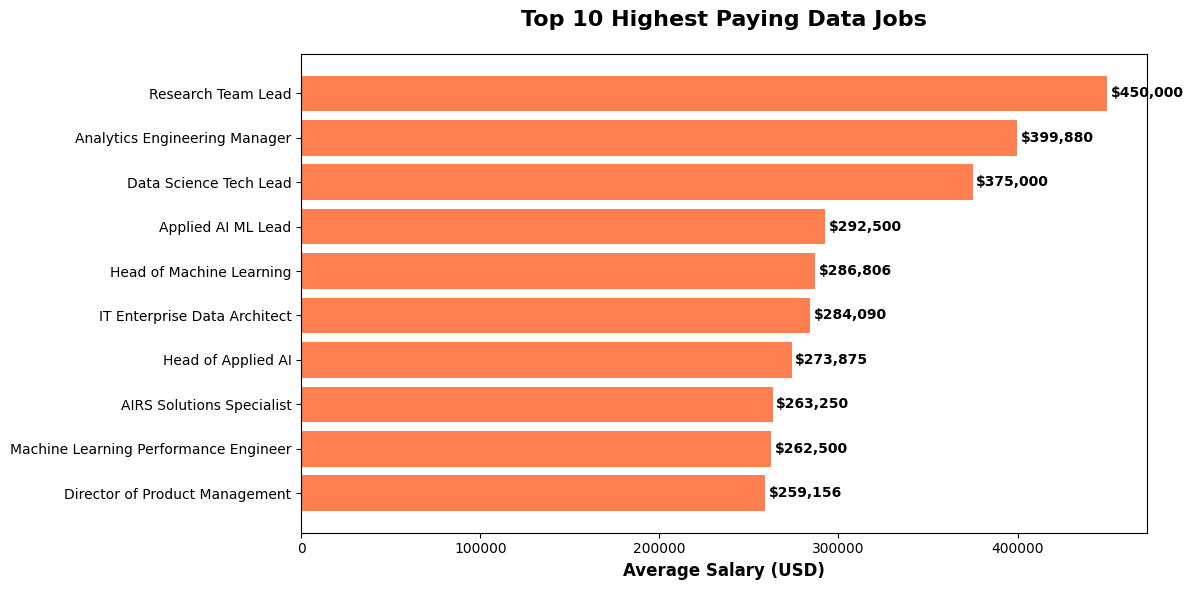

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

top_roles_sorted = top_roles.sort_values(ascending=True)
ax.barh(top_roles_sorted.index, top_roles_sorted.values, color='coral')
ax.set_title("Top 10 Highest Paying Data Jobs", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Average Salary (USD)", fontsize=12, fontweight='bold')

for i, v in enumerate(top_roles_sorted.values):
    ax.text(v + 2000, i, f"${v:,.0f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Salary by Experience Level & Remote Work Distribution

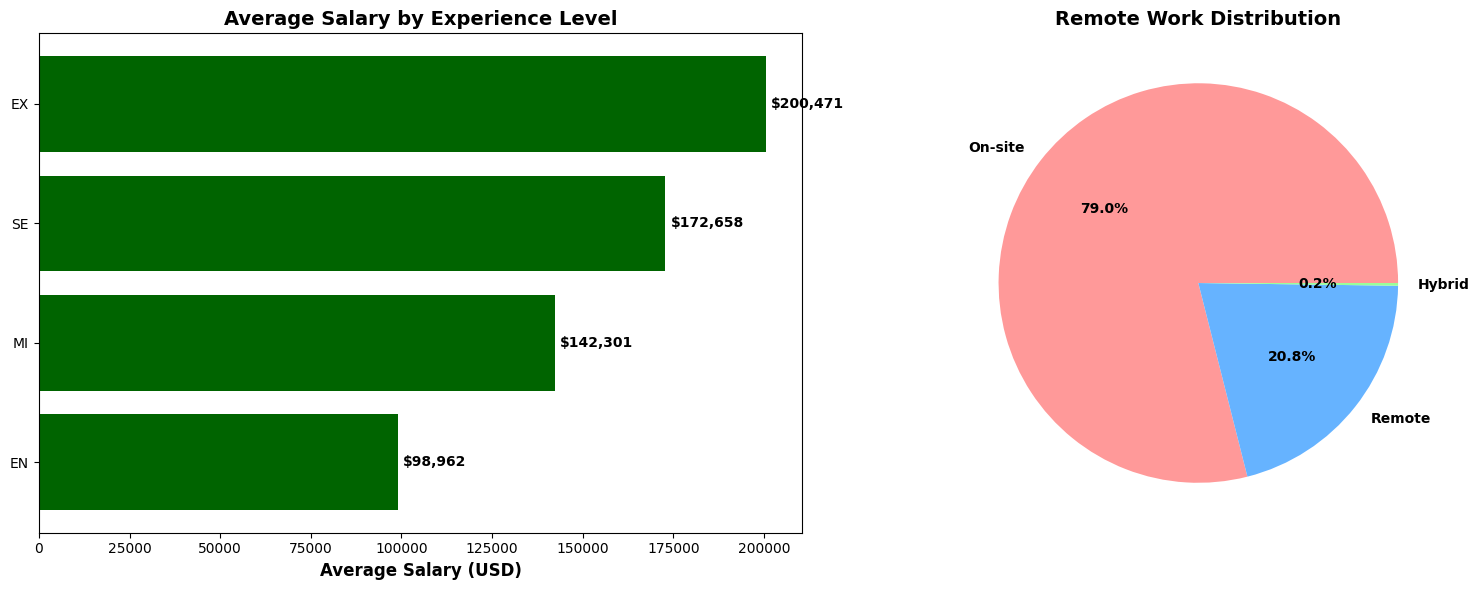

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Salary by Experience Level
salary_exp = df.groupby("experience_level")["salary_in_usd"].mean().sort_values(ascending=True)
axes[0].barh(salary_exp.index, salary_exp.values, color='darkgreen')
axes[0].set_title("Average Salary by Experience Level", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Average Salary (USD)", fontsize=12, fontweight='bold')

for i, v in enumerate(salary_exp.values):
    axes[0].text(v + 1500, i, f"${v:,.0f}", va='center', fontweight='bold')

# Remote Work Distribution
remote_jobs = df['remote_ratio'].value_counts()
labels = {0: 'On-site', 50: 'Hybrid', 100: 'Remote'}
remote_labels = [labels.get(x, str(x)) for x in remote_jobs.index]
axes[1].pie(remote_jobs.values, labels=remote_labels, autopct="%1.1f%%",
            colors=['#ff9999', '#66b3ff', '#99ff99'], textprops={'fontweight': 'bold'})
axes[1].set_title("Remote Work Distribution", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Top Hiring Countries & Salary by Company Size

In [6]:
top_locations = df["company_location"].value_counts().head(10)

print("\n" + "="*80)
print("TOP 10 HIRING COUNTRIES")
print("="*80 + "\n")
for i, (loc, count) in enumerate(top_locations.items(), 1):
    print(f"  {i:>2}. {loc:<30} {count:>6} jobs")
print("\n" + "="*80 + "\n")


TOP 10 HIRING COUNTRIES

   1. US                             135569 jobs
   2. CA                               6208 jobs
   3. GB                               4181 jobs
   4. AU                                595 jobs
   5. NL                                482 jobs
   6. DE                                455 jobs
   7. FR                                437 jobs
   8. LT                                372 jobs
   9. AT                                355 jobs
  10. ES                                307 jobs




## Charts — Hiring Countries & Salary by Company Size

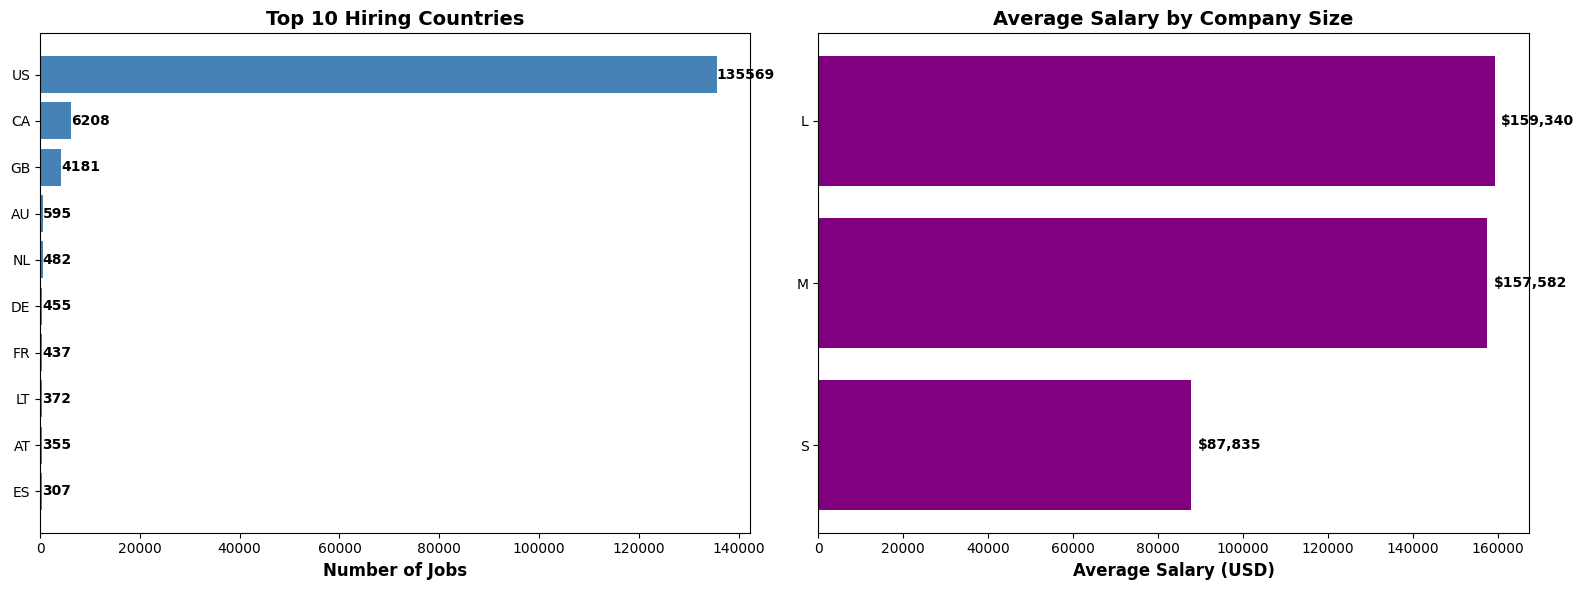

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top Hiring Countries
top_locs = top_locations.sort_values(ascending=True)
axes[0].barh(top_locs.index, top_locs.values, color='steelblue')
axes[0].set_title("Top 10 Hiring Countries", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Number of Jobs", fontsize=12, fontweight='bold')

for i, v in enumerate(top_locs.values):
    axes[0].text(v + 5, i, str(int(v)), va='center', fontweight='bold')

# Salary by Company Size
salary_company = df.groupby("company_size")["salary_in_usd"].mean().sort_values(ascending=True)
axes[1].barh(salary_company.index, salary_company.values, color='purple')
axes[1].set_title("Average Salary by Company Size", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Average Salary (USD)", fontsize=12, fontweight='bold')

for i, v in enumerate(salary_company.values):
    axes[1].text(v + 1500, i, f"${v:,.0f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Most In-Demand Data Jobs


TOP 10 MOST IN-DEMAND DATA JOBS

   1. Data Scientist                                 18751 postings
   2. Software Engineer                              16948 postings
   3. Data Engineer                                  16352 postings
   4. Data Analyst                                   13779 postings
   5. Engineer                                       11004 postings
   6. Machine Learning Engineer                       8887 postings
   7. Manager                                         7811 postings
   8. Analyst                                         5396 postings
   9. Research Scientist                              3460 postings
  10. Product Manager                                 2576 postings




C:\Users\HP\AppData\Local\Temp\ipykernel_21268\1365029938.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_jobs_sorted.values, y=top_jobs_sorted.index, palette="Blues_r", ax=ax)


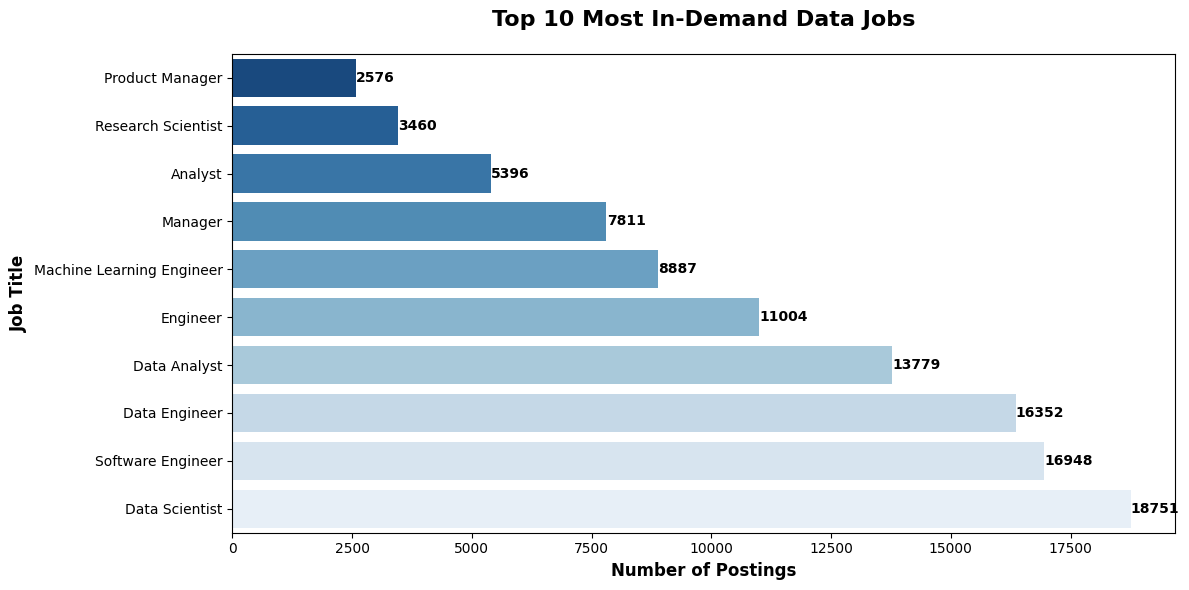

In [8]:
top_jobs = df["job_title"].value_counts().head(10)

print("\n" + "="*80)
print("TOP 10 MOST IN-DEMAND DATA JOBS")
print("="*80 + "\n")
for i, (job, count) in enumerate(top_jobs.items(), 1):
    print(f"  {i:>2}. {job:<45} {count:>6} postings")
print("\n" + "="*80 + "\n")

fig, ax = plt.subplots(figsize=(12, 6))

top_jobs_sorted = top_jobs.sort_values(ascending=True)
sns.barplot(x=top_jobs_sorted.values, y=top_jobs_sorted.index, palette="Blues_r", ax=ax)
ax.set_title("Top 10 Most In-Demand Data Jobs", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Number of Postings", fontsize=12, fontweight='bold')
ax.set_ylabel("Job Title", fontsize=12, fontweight='bold')

for i, v in enumerate(top_jobs_sorted.values):
    ax.text(v + 5, i, str(int(v)), va='center', fontweight='bold')

plt.tight_layout()
plt.show()